# Homework 04: Matplotlib & NumPy

**Release Date:** Feb 27

**Due Date:** Mar 13 11:59 PM

**Total Points:** 60 pts

**Instructions:**
- Complete all problems in this notebook
- Show all your work with clear comments
- Use appropriate variable names
- Format all outputs professionally with units
- Test your code to ensure it runs without errors

**Submission:**
- Submit this completed Jupyter notebook to Gradescope
- Make sure all cells have been executed and outputs are visible

---
## Problem 1 (20 points): Python List vs NumPy — Speed and Convenience

NumPy's vectorized operations run far faster than Python `for` loops because they execute compiled C code on contiguous memory blocks, bypassing Python's per-element overhead.

You have $N = 1{,}000{,}000$ pressure measurements (in Pa) from a reactor. Using the same data as both a NumPy array and a Python list:

1. **List implementation** — use a `for` loop to convert Pa → atm (÷ 101325), compute the mean, and count readings above 3.0 atm. Time the calculation with `time.time()`.
2. **NumPy implementation** — repeat using vectorized operations (no loops). Time it the same way.

**Timing pattern:**
```python
import time
start = time.time()
# ... your code ...
elapsed = time.time() - start
```
**Creating random 1,000,000 points
```python
import numpy as np
P_array = np.random.uniform(start, end, number of points) 
```

In [15]:
import numpy as np
import time

np.random.seed(42)
P_array = np.random.uniform(100000, 600000, 1_000_000)  # Pa
P_list  = list(P_array)

# --- Task 1: List implementation ---
start = time.time()
P_atm_list = [p / 101325 for p in P_list]
mean_list  = sum(P_atm_list) / len(P_atm_list)
count_list = sum(1 for p in P_atm_list if p > 3.0)
t_list = time.time() - start

# --- Task 2: NumPy implementation ---
start = time.time()
P_atm_np  = P_array / 101325
mean_np   = np.mean(P_atm_np)
count_np  = np.sum(P_atm_np > 3.0)
t_numpy = time.time() - start

# --- Task 3: Results, verification, speedup ---
print(f"Mean (list):  {mean_list:.4f} atm    Mean (NumPy): {mean_np:.4f} atm")
print(f"Count > 3 atm (list): {count_list}    (NumPy): {int(count_np)}")
print(f"Results match: mean {abs(mean_list - mean_np) < 1e-4}, count {count_list == int(count_np)}")
print(f"\nList time:  {t_list:.4f} s")
print(f"NumPy time: {t_numpy:.6f} s")
print(f"Speedup:    {t_list / t_numpy:.1f}x")

Mean (list):  3.4559 atm    Mean (NumPy): 3.4559 atm
Count > 3 atm (list): 592476    (NumPy): 592476
Results match: mean True, count True

List time:  0.0859 s
NumPy time: 0.002477 s
Speedup:    34.7x


---
### Batch Reactor Schematic

The diagram below shows a **jacketed batch reactor**. The heating fluid circulates through the jacket, transferring heat through the reactor wall to raise the contents from $T_0$ to the setpoint $T_\infty$.

```
                         JACKETED BATCH REACTOR
                         ═══════════════════════

                        ┌─────────────────────────┐
                        │     Condenser /         │
                        │     Reflux line         │
                        └───────────┬─────────────┘
                                    │  
               ╔════════════════════┪════════════════════╗  
               ║                    │                    ║
               ║            ╔═══════╩═══════╗            ║
               ║            ║               ║            ║
  Jacket  ═════╣░░░░░░░░░░░░║  Reactor      ║░░░░░░░░░░░░╠════  Jacket
  inlet        ║░░░░░░░░░░░░║  contents     ║░░░░░░░░░░░░║        outlet
  T_jacket     ║░░░░░░░░░░░░║  (well-mixed) ║░░░░░░░░░░░░║
  (heating     ║░░░░░░░░░░░░║  T(t):        ║░░░░░░░░░░░░║
  fluid)       ║░░░░░░░░░░░░║  298 → 450 K  ║░░░░░░░░░░░░║
               ║░░░░░░░░░░░░║  A → B        ║░░░░░░░░░░░░║
               ║            ║    ╬          ║            ║
               ║            ║  Impeller     ║            ║
               ║            ╚═══════════════╝            ║
               ╚═════════════════════════════════════════╝


  Heat transfer:   Q = U · A_wall · (T_jacket − T)
  Temperature:     T(t) = T∞ − (T∞ − T₀) · exp(−αt),   α = U·A_wall/(ρ·V·cₚ)
  Rate constant:   k(T) = A · exp(−Eₐ/RT)

  k(298 K) ≈ 0.17 min⁻¹  →  k(450 K) ≈ 157 min⁻¹   (~913× increase)
```

---
## Problem 2 (40 points): Combined NumPy + Matplotlib — Reactor Temperature Profile

A batch reactor heats from ambient temperature (298 K) to a setpoint of 450 K following:

$$
T(t) = T_{\infty} - (T_{\infty} - T_0)\, e^{-\alpha t}
$$

with $T_0 = 298$ K, $T_\infty = 450$ K, $\alpha = 0.15$ min⁻¹, over $t = 0$ to $30$ min.

The reaction rate constant follows the Arrhenius equation:

$$
k(T) = A \, e^{-E_a / (RT)}
$$

with $A = 1.0 \times 10^8$ min⁻¹, $E_a = 50{,}000$ J/mol, $R = 8.314$ J/(mol·K).

**Tasks:**

1. Create a 2×1 subplot figure (figsize=(8, 8)) at \alpha = 0.15 \,\text{min}^{-1} using NumPy (no loops). Also print the maximum rate constant and the time at which it occurs:
   - **Top:** Temperature (K) vs. Time (min)
   - **Bottom:** k (min⁻¹) vs. Time (min)
   - Print the **maximum k** and the **time at which it occurs**.
2. Plot **T(t) for $\alpha = 0.05,\ 0.15,\ 0.50$ min⁻¹** on the same figure. Label each curve with its $\alpha$ and $\tau = 1/\alpha$. Add a horizontal dashed line at $T_\infty$, title, legend.
3.  From your Task 3 plot, what does $\tau = 1/\alpha$ physically represent? How does smaller $\alpha$ affect the reaction?

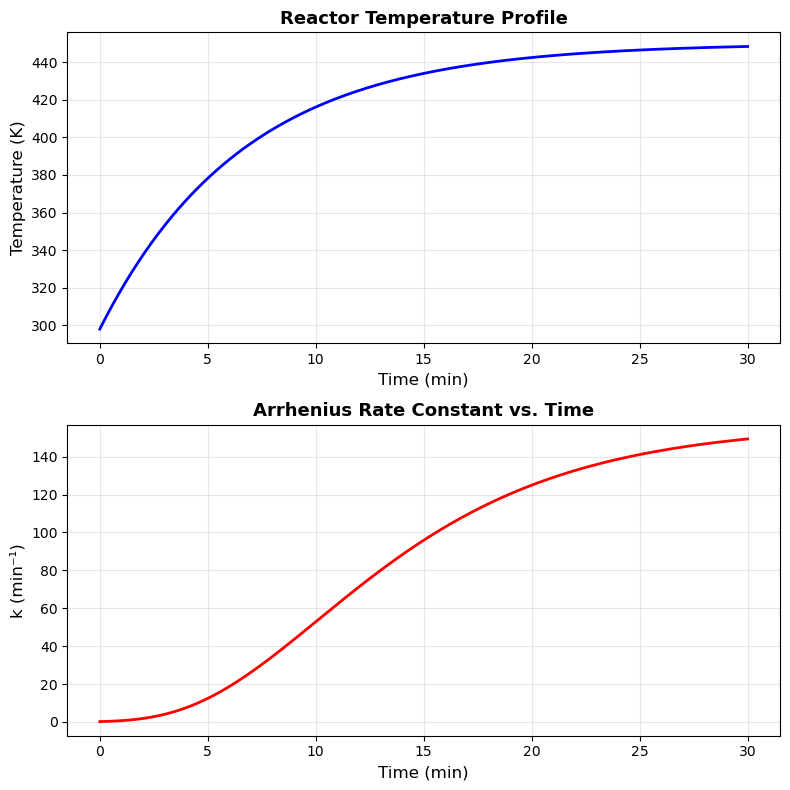

Max k = 1.4931e+02 min⁻¹  at  t = 30.00 min


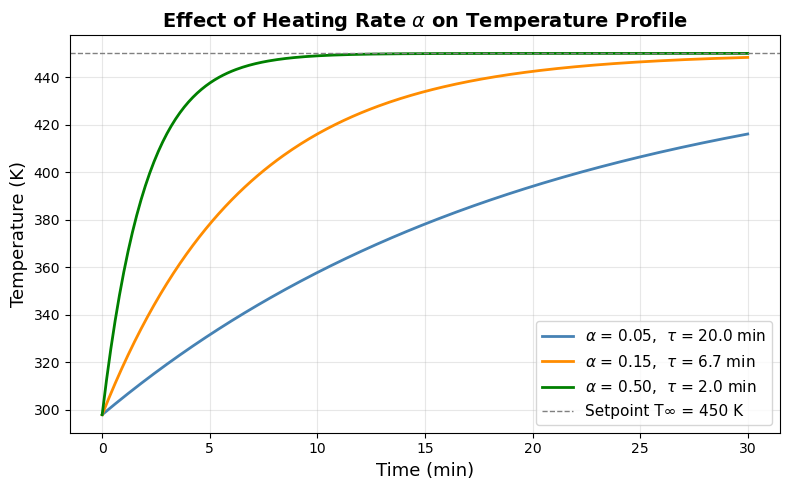

In [14]:
import numpy as np
import matplotlib.pyplot as plt

T0    = 298.0;  T_inf = 450.0;  alpha = 0.15
A     = 1.0e8;  Ea    = 50000.0; R    = 8.314

t = np.linspace(0, 30, 300)

# Tasks 1 & 2
T = T_inf - (T_inf - T0) * np.exp(-alpha * t)
k = A * np.exp(-Ea / (R * T))

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
axes[0].plot(t, T, 'b-', linewidth=2)
axes[0].set_xlabel('Time (min)', fontsize=12); axes[0].set_ylabel('Temperature (K)', fontsize=12)
axes[0].set_title('Reactor Temperature Profile', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, k, 'r-', linewidth=2)
axes[1].set_xlabel('Time (min)', fontsize=12); axes[1].set_ylabel('k (min⁻¹)', fontsize=12)
axes[1].set_title('Arrhenius Rate Constant vs. Time', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Max k = {np.max(k):.4e} min⁻¹  at  t = {t[np.argmax(k)]:.2f} min")

# Task 3: Effect of alpha
alphas = [0.05, 0.15, 0.50]
colors = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(8, 5))
for a, c in zip(alphas, colors):
    T_a = T_inf - (T_inf - T0) * np.exp(-a * t)
    plt.plot(t, T_a, color=c, linewidth=2,
             label=f'$\\alpha$ = {a:.2f},  $\\tau$ = {1/a:.1f} min')
plt.axhline(T_inf, color='gray', linestyle='--', linewidth=1,
            label=f'Setpoint T∞ = {T_inf:.0f} K')
plt.xlabel('Time (min)', fontsize=13); plt.ylabel('Temperature (K)', fontsize=13)
plt.title('Effect of Heating Rate $\\alpha$ on Temperature Profile', fontsize=14, fontweight='bold')
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

**Discussion (Task 4):**

$\tau = 1/\alpha$ is the time to close 63% of the gap between current temperature and setpoint $T_\infty$. From the Task 3 plot, a slow heater ($\alpha = 0.05$, $\tau = 20$ min) barely reaches setpoint within 30 min — the reactor lingers at low temperatures where $k$ is negligible, wasting batch time. A fast heater ($\alpha = 0.50$, $\tau = 2$ min) reaches $T_\infty$ almost immediately, maximizing time at high $k$.

